### 1. Environment setup

In [ ]:
URL='http://github.com/jasongrout/minimum_rank/raw/minimum_rank_1_1_3/'
files=['minrank.py']
for f in files:
    load(URL+f)
    
import csv

Loading minrank.py...


### 2. Defining `is_directly_forceable`

In [17]:
def is_directly_forceable(graph, verbose=False, return_details=False):
    """
    Determines if a graph is directly forceable.
    
    Args:
        graph: The graph to analyze
        verbose: If True, prints detailed information
        return_details: If True, returns forcing sequences along with result
        
    Returns:
        If return_details is False:
            graph6 string if directly forceable, None otherwise
        If return_details is True:
            (graph6 string, forcing set, forcing sequence) if directly forceable, None otherwise
    """
    # Find all optimal zero forcing sets. Could be improved by immediately determining if an optimal zero forcing set is a directly forceable set instead of printing all optimal sets.
    zfset = zero_forcing_set_bruteforce(graph, all_sets=True)
    zg = find_Z(graph)
    n = graph.order()
    
    # Zero forcing number equals number of vertices
    if zg == n:
        if verbose:
            print("The graph is directly forceable because Z(G)=n.")
        return graph.graph6_string() if not return_details else (graph.graph6_string(), None, None)
    
    # Check if zero forcing number is within range
    if (n/2) <= zg <= (n - 1):
        for Z in zfset:
            # Initialize coloring
            color = {v: 'white' for v in graph.vertices()}
            for v in Z:
                color[v] = 'blue'
            
            # Apply forcing rule
            changed = True
            counter = 0
            fseq = []  # Forcing sequence
            
            while counter < zg:  # Stop after zg iterations without color changes
                changed = False
                for v in Z:
                    # Get uncolored neighbors of vertex v
                    uncolored_neighbors = [u for u in graph.neighbors(v) if color[u] == 'white']
                    # Apply the color forcing rule
                    if len(uncolored_neighbors) == 1:
                        color[uncolored_neighbors[0]] = 'blue'
                        changed = True
                        fseq.append((v, uncolored_neighbors[0]))
                if changed:
                    counter = 0 # Reset counter if change occurred
                else:
                    counter += 1
            
            # Check if all vertices are colored
            if all(color[v] == 'blue' for v in graph.vertices()):
                if verbose:
                    print("The graph is directly forceable.")
                    print(f"Optimal zero forcing set {Z} has the forcing sequence: {fseq}")
                return graph.graph6_string() if not return_details else (graph.graph6_string(), Z, fseq)
        
        # No forcing set worked
        if verbose:
            print(f"The graph is not directly forceable.")
        return None
    else:
        # Zero forcing number is out of bound
        if verbose:
            print("The graph is not directly forceable: Z(G) out of bound.")
        return None

### 3. Example usage

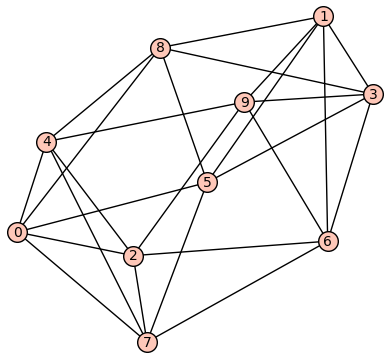

The graph is directly forceable.
Optimal zero forcing set {0, 1, 4, 5, 8} has the forcing sequence: [(8, 3), (5, 7), (0, 2), (4, 9), (1, 6)]


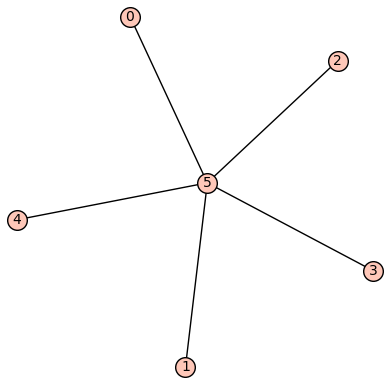

The graph is not directly forceable.


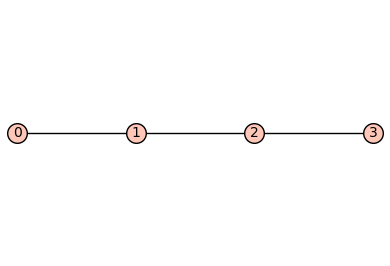

The graph is not directly forceable: Z(G) out of bound.


In [42]:
# Example use of is_directly_forceable()

E={0:[2,4,5,7,8],1:[5,3,6,9,8],2:[7,4,6,9],3:[6,5,8,9],4:[7,8,9],5:[8,7],6:[7,9]}
k = Graph(E)
g=Graph('E?Bw')
p = graphs.PathGraph(4)

show(k)
is_directly_forceable(k, verbose=True, return_details=True)

show(g)
is_directly_forceable(g, verbose=True, return_details=True)

show(p)
is_directly_forceable(p, verbose=True, return_details=True)